## Overall Structure
We begin by creating a population matrix for each ethnicity and gender combination, where:

Each row represents a unique agent (individual).

Each column represents a calendar year.

The time span is divided into two :

Retrospective years (1990–2023) for historical analysis.

Projection years (2024–2050) for future forecasting.

and therefore we will have two set of matrices, for this file, we only show matrices of retrospective years `age_matrix_vec`

The values in the matrix represent the age of each agent in a given year:

A value of -1 indicates that the agent is either not yet born or has already died in that year.


## Disease Mapping
Once the population matrix is established, we perform matrix mapping using disease-specific transition rates to simulate health outcomes. This results in corresponding disease state matrices.

Examples:
Diabetes Matrices `diabetes_mat_list`

Values:

0 = Healthy

0.5 = Pre-diabetes

1 = Diabetes

Hypertension Matrices `hyper_mat_list`

Values:

0 = Healthy

1 = Hypertension



In this case, that we don't use struct but use matrix directly. 

Through it may be hard to read and understand, but it's faster for the matrix operations. 

In [272]:
from impute_bmi import calculate_bmi,apply_bmi,bmitable

In [ ]:
# bmi_samples_dict = {}

# for group in range(N):
#     bmi_samples_dict[group] = {}
#     for key, value in age_dict[group].items():
#         age = key
#         age_vector = np.arange(18, key + 1)
#         year_born = 1990 - key 
#         # Repeat the BMI calculation for 'value' times
#         bmi_samples = np.array([calculate_bmi(age_vector, year_born, group, bmitable, height=170.0) for _ in range(value)])
#         bmi_samples_dict[group][age] = bmi_samples

In [ ]:
# # Create directory if it doesn't exist
# import os
# save_dir = "../future_data/bmi_samples"
# os.makedirs(save_dir, exist_ok=True)

# for group in range(N):
#     for key, value in bmi_samples_dict[group].items():
#         save_path = os.path.join(save_dir, f"bmi_samples_group{group}_age{key}.npy")
#         np.save(save_path, value)

# get 1990 - 2023 population as well

In [ ]:
# num_files = 8  # Change this to the actual number of files to read

# age_matrix_vec_2023 = []

# path = "/Users/haolong/Documents/demos_v_matrix/output/"
# for i in range(num_files):
#     # Create the filename dynamically

#     filename = f"popu_matrix_{i}.csv"
#     matrix = pd.read_csv(path + filename).to_numpy() # convert to numpy
#     age_matrix_vec_2023.append(matrix)

# for idx in range(8):
#     matrix = age_matrix_vec_2023[idx]  # Extract the matrix
#     # Check each row, and keep it if not all values are negative
#     filtered_matrix = matrix[~np.all(matrix < 0, axis=1)]
#     age_matrix_vec_2023[idx] = filtered_matrix



In [274]:
# Load all age matrices from the saved files
age_matrix_vec = []
age_dir = '../future_data_1990_2050/age_matrix/'

for i in range(8):
    filename = f"age_matrix_{i}.npy"
    file_path = os.path.join(age_dir, filename)
    age_matrix = np.load(file_path)
    # Handle the additional simulation dimension
    # Filter out negative values across the last two dimensions (keeping simulation dimension)
    if len(age_matrix.shape) == 3:  # (simulation_times, individuals, years)
        filtered_matrix = age_matrix[:, ~np.all(age_matrix < 0, axis=2).any(axis=0)]
    else:  # Fallback for 2D case
        filtered_matrix = age_matrix[~np.all(age_matrix < 0, axis=1)]
    age_matrix_vec.append(filtered_matrix)
    print(f"Loaded: {file_path} with shape {filtered_matrix.shape}")

print(f"\nLoaded {len(age_matrix_vec)} age matrices into age_matrix_vec")


Loaded: ../future_data_1990_2050/age_matrix/age_matrix_0.npy with shape (11, 93313, 61)
Loaded: ../future_data_1990_2050/age_matrix/age_matrix_1.npy with shape (11, 98580, 61)
Loaded: ../future_data_1990_2050/age_matrix/age_matrix_2.npy with shape (11, 27967, 61)
Loaded: ../future_data_1990_2050/age_matrix/age_matrix_3.npy with shape (11, 28560, 61)
Loaded: ../future_data_1990_2050/age_matrix/age_matrix_4.npy with shape (11, 16358, 61)
Loaded: ../future_data_1990_2050/age_matrix/age_matrix_5.npy with shape (11, 14479, 61)
Loaded: ../future_data_1990_2050/age_matrix/age_matrix_6.npy with shape (11, 5976, 61)
Loaded: ../future_data_1990_2050/age_matrix/age_matrix_7.npy with shape (11, 6742, 61)

Loaded 8 age matrices into age_matrix_vec


### create albuminuria matrices from 1990 - 2050 

In [81]:
from impute_albu import schedule_pre_albuminuria_probability,schedule_albuminuria_probability
from Age_BMI_loading import age_dict

In [82]:
from prevalence import get_prevalence,get_pre_prevalence,get_overall_prevalence,get_overall_pre_prevalence

In [275]:
# Fix the IndexError by ensuring age_mat is converted to integer type for array indexing

age_matrix_vec

# Convert all age matrices to integer type to fix IndexError
for i in range(len(age_matrix_vec)):
    age_matrix_vec[i] = age_matrix_vec[i].astype(int)
    print(f"age_matrix_vec[{i}] data type after conversion: {age_matrix_vec[i].dtype}")

age_matrix_vec[0] data type after conversion: int64
age_matrix_vec[1] data type after conversion: int64
age_matrix_vec[2] data type after conversion: int64
age_matrix_vec[3] data type after conversion: int64
age_matrix_vec[4] data type after conversion: int64
age_matrix_vec[5] data type after conversion: int64
age_matrix_vec[6] data type after conversion: int64
age_matrix_vec[7] data type after conversion: int64


In [277]:
# get 1990 
albu_status_dict = {}
albu_mat_list_overall = []
A_range = [0.001,0.002,0.003,0.004,0.005]

for A in A_range:
    albu_status_dict = {}
    for group in range(N):
        i = group
        albu_status_dict[group] = {}
        # age_matrix_vec[i] now has shape (simulation_times, individuals, years)
        n_simulations, n_individuals, n_years = age_matrix_vec[i].shape
        albu_status = np.zeros((n_simulations, n_individuals, n_years))  
        for age in age_dict[group]:
            # bmi_samples = bmi_samples_dict[group][age]  # shape: (n_samples, n_ages)
            #n_samples, n_ages = bmi_samples.shape
            # Create an age matrix with shape (n_samples, n_ages)
            n_samples = age_dict[group][age]
            age_mat = np.tile(np.arange(18, age + 1), (n_samples, 1))
            # idx = group

            # Compute prediabetes probability matrix
            prediabetes_prob_matrix = schedule_pre_albuminuria_probability(age_mat,i,A)
            rand_matrix = np.random.rand(*age_mat.shape)
            prediabetes_matrix = (rand_matrix < prediabetes_prob_matrix) * 0.5
            prediabetes_matrix = np.maximum.accumulate(prediabetes_matrix, axis=1)

            # Compute albu probability matrix
            albu_prob_matrix = schedule_albuminuria_probability(age_mat,i)
            rand_matrix = np.random.rand(*age_mat.shape)
            albu_matrix = np.where(rand_matrix < albu_prob_matrix, 1, 0.5)

            # Combine: take max along each row (for each sample)
            combined_matrix = np.where(prediabetes_matrix == 0.5, albu_matrix, prediabetes_matrix)
            combined_matrix = np.maximum.accumulate(combined_matrix, axis=1)

            albu_status_dict[group][age] = np.max(combined_matrix, axis=1)

    
    albu_mat_list = []
    pre_albu_mat_list = []
    for i in range(8):
        # age_matrix_vec[i] now has shape (simulation_times, individuals, years)
        n_simulations, n_individuals, n_years = age_matrix_vec[i].shape
        albu_status = np.zeros((n_simulations, n_individuals, n_years))  
        for age, status_vec in albu_status_dict[i].items():
            # Find positions where the first column (first year) of age_matrix_vec[i] equals 'age'
            # We need to handle all simulations
            for sim in range(n_simulations):
                positions = np.where(age_matrix_vec[i][sim, :, 0] == age)[0]
                # Assign the albu status vector for this age group
                albu_status[sim, positions, 0] = status_vec

        # Repeat the first column across all years for each simulation
        albu_status_before = np.repeat(albu_status[:, :, 0][:, :, np.newaxis], n_years, axis=2)
        # Process albu status
        # bmi_mat = bmi_matrix_ls[i]
        age_mat = age_matrix_vec[i]

        pre_albu_prob_matrix = schedule_pre_albuminuria_probability(age_mat, i, A)
        rand_matrix = np.random.rand(*age_mat.shape)
        pre_albu_matrix = (rand_matrix < pre_albu_prob_matrix) * 0.5
        
        pre_albu_matrix = np.where(albu_status_before == 0, pre_albu_matrix, albu_status_before)
        pre_albu_matrix = np.maximum.accumulate(pre_albu_matrix, axis=2)
        pre_albu_mat_list.append(pre_albu_matrix)
        
        albu_prob_matrix = schedule_albuminuria_probability(age_mat, i)
        rand_matrix = np.random.rand(*age_mat.shape)
        albu_matrix = np.where(rand_matrix < albu_prob_matrix, 1, 0.5)
        
        combined_matrix = np.where(pre_albu_matrix == 0.5, albu_matrix, pre_albu_matrix)

        albu_status[:, :, 1:] = combined_matrix[:, :, 1:]
        albu_status = np.maximum.accumulate(albu_status, axis=2)
        albu_mat_list.append(albu_status)

    overall_prevalence = get_overall_prevalence(age_matrix_vec,albu_mat_list,-2)
    overall_pre_prevalence = get_overall_pre_prevalence(age_matrix_vec,albu_mat_list,-2)

    print(f"A = {A}: Overall prevalence = {overall_prevalence:.4f}, Overall pre-prevalence = {overall_pre_prevalence:.4f}")
    
    # Store the albu_mat_list for this A value
    albu_mat_list_overall.append(albu_mat_list)

# Load albuminuria matrices for different A values
import os




N = 8

# Create albu_1_mat_storage: list of arrays where each array has shape (len(A_range), albu_matrix.shape[0], albu_matrix.shape[1], albu_matrix.shape[2])
albu_mat_storage = []

# For each group i, create an array that stacks matrices from all A values
for i in range(N):
    # Get the shape from the first A value's matrix for group i
    first_matrix = albu_mat_list_overall[0][i]  # A_range[0], group i
    matrix_shape = first_matrix.shape
    
    # Initialize array to hold matrices for all A values for this group
    # Shape: (len(A_range), simulation_times, individuals, years)
    group_array = np.zeros((len(A_range), matrix_shape[0], matrix_shape[1], matrix_shape[2]))
    
    # Fill the array with matrices from each A value
    for A_idx in range(len(A_range)):
        group_array[A_idx] = albu_mat_list_overall[A_idx][i]
    
    albu_mat_storage.append(group_array)





A = 0.001: Overall prevalence = 0.0000, Overall pre-prevalence = 0.0688
A = 0.002: Overall prevalence = 0.0000, Overall pre-prevalence = 0.0811
A = 0.003: Overall prevalence = 0.0025, Overall pre-prevalence = 0.0614
A = 0.004: Overall prevalence = 0.0000, Overall pre-prevalence = 0.0958
A = 0.005: Overall prevalence = 0.0197, Overall pre-prevalence = 0.1229


In [214]:
albu_mat_storage[0].shape

(2, 93313, 61)

In [215]:
# Save all matrices in albu_1_mat_storage to npy files
# Create directory if it doesn't exist

os.makedirs('../future_data_1990_2050/albu_matrix_2', exist_ok=True)
print("Created directory: ../future_data_1990_2050/albu_matrix_2")

for i, group_array in enumerate(albu_mat_storage):
    filename = f'../future_data_1990_2050/albu_matrix_2/albu_1_mat_group_{i}.npy'
    np.save(filename, group_array)
    print(f"Saved group {i} array to {filename}")



Created directory: ../future_data_1990_2050/albu_matrix_2
Saved group 0 array to ../future_data_1990_2050/albu_matrix_2/albu_1_mat_group_0.npy
Saved group 1 array to ../future_data_1990_2050/albu_matrix_2/albu_1_mat_group_1.npy
Saved group 2 array to ../future_data_1990_2050/albu_matrix_2/albu_1_mat_group_2.npy
Saved group 3 array to ../future_data_1990_2050/albu_matrix_2/albu_1_mat_group_3.npy
Saved group 4 array to ../future_data_1990_2050/albu_matrix_2/albu_1_mat_group_4.npy
Saved group 5 array to ../future_data_1990_2050/albu_matrix_2/albu_1_mat_group_5.npy
Saved group 6 array to ../future_data_1990_2050/albu_matrix_2/albu_1_mat_group_6.npy
Saved group 7 array to ../future_data_1990_2050/albu_matrix_2/albu_1_mat_group_7.npy


In [264]:
# Load the saved matrices and check their sizes
albu_mat_storage = []
for i in range(8):
    filename = f'../future_data_1990_2050/albu_matrix_2/albu_1_mat_group_{i}.npy'
    loaded_array = np.load(filename) * 2
    albu_mat_storage.append(loaded_array)
    print(f"Loaded group {i} array from {filename}, shape: {loaded_array.shape}")

Loaded group 0 array from ../future_data_1990_2050/albu_matrix_2/albu_1_mat_group_0.npy, shape: (2, 93313, 61)
Loaded group 1 array from ../future_data_1990_2050/albu_matrix_2/albu_1_mat_group_1.npy, shape: (2, 98580, 61)
Loaded group 2 array from ../future_data_1990_2050/albu_matrix_2/albu_1_mat_group_2.npy, shape: (2, 27967, 61)
Loaded group 3 array from ../future_data_1990_2050/albu_matrix_2/albu_1_mat_group_3.npy, shape: (2, 28560, 61)
Loaded group 4 array from ../future_data_1990_2050/albu_matrix_2/albu_1_mat_group_4.npy, shape: (2, 16358, 61)
Loaded group 5 array from ../future_data_1990_2050/albu_matrix_2/albu_1_mat_group_5.npy, shape: (2, 14479, 61)
Loaded group 6 array from ../future_data_1990_2050/albu_matrix_2/albu_1_mat_group_6.npy, shape: (2, 5976, 61)
Loaded group 7 array from ../future_data_1990_2050/albu_matrix_2/albu_1_mat_group_7.npy, shape: (2, 6742, 61)


In [217]:
from prevalence import get_prevalence,get_pre_prevalence,get_overall_prevalence,get_overall_pre_prevalence

In [218]:
age_matrix_vec[7].shape

(6742, 61)

In [99]:
albu_mat_list[7].shape

(6742, 61)

In [219]:
# check the prevalence of albu
albu_mat_list = []
pre_albu_mat_list = []
for matrix in albu_1_mat_storage:
        # Extract the first 2D slice (mat[0,:,:]) and append to list
        matrix_2d = matrix[1, :, :]
        albu_mat_list.append(matrix_2d)
        
for k in range(-61, 0):    
    overall_prevalence = get_overall_prevalence(age_matrix_vec, albu_mat_list, k)   
    pre_albu_mat_list.append(overall_prevalence)
    

In [220]:
albu_1_mat_storage[0].shape

(2, 93313, 61)

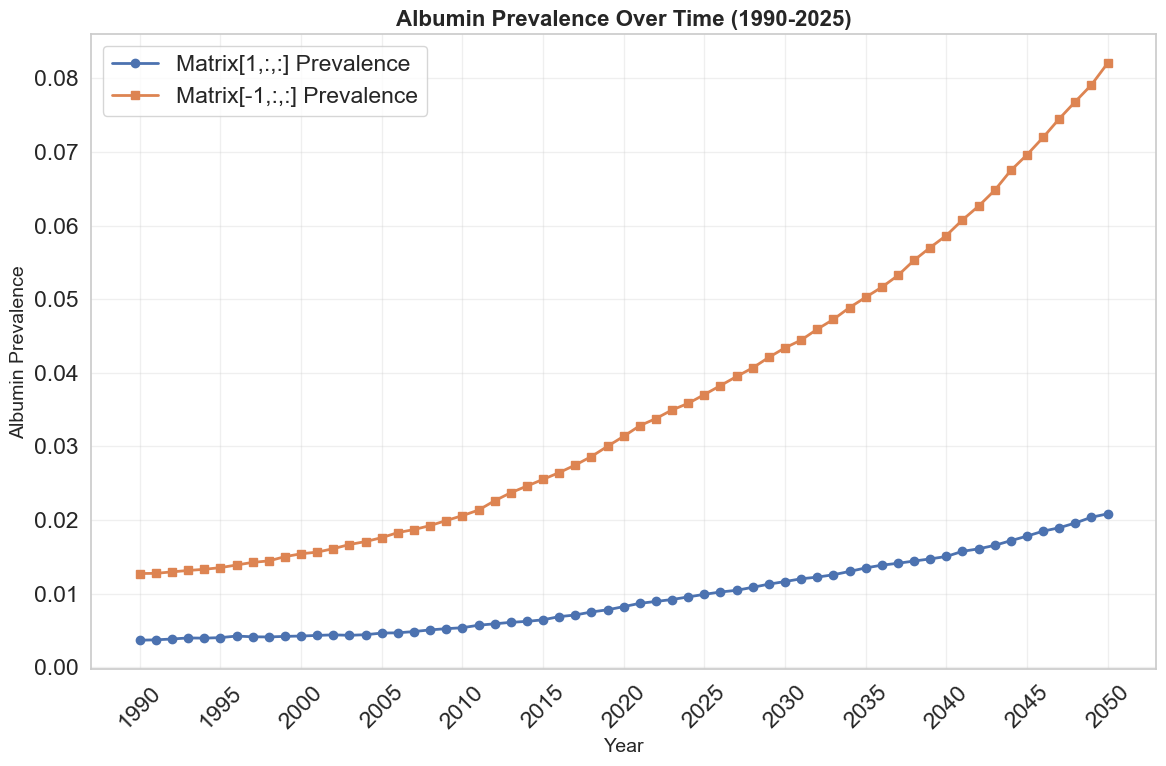

Number of data points: 61
Matrix[1,:,:] - Starting prevalence (1990): 0.003679
Matrix[1,:,:] - Ending prevalence (2050): 0.020846
Matrix[1,:,:] - Change over time: 0.017168
Matrix[-1,:,:] - Starting prevalence (1990): 0.012738
Matrix[-1,:,:] - Ending prevalence (2050): 0.082076
Matrix[-1,:,:] - Change over time: 0.069338


In [221]:
import matplotlib.pyplot as plt

# check the prevalence of albu
albu_mat_list_first = []
albu_mat_list_last = []
pre_albu_mat_list_first = []
pre_albu_mat_list_last = []

for matrix in albu_1_mat_storage:
        # Extract matrix[1,:,:] and matrix[-1,:,:] 
        matrix_2d_first = matrix[0, :, :]
        matrix_2d_last = matrix[-1, :, :]
        albu_mat_list_first.append(matrix_2d_first)
        albu_mat_list_last.append(matrix_2d_last)
        
for k in range(-61, 0):    
    overall_prevalence_first = get_overall_prevalence(age_matrix_vec, albu_mat_list_first, k)   
    overall_prevalence_last = get_overall_prevalence(age_matrix_vec, albu_mat_list_last, k)   
    pre_albu_mat_list_first.append(overall_prevalence_first)
    pre_albu_mat_list_last.append(overall_prevalence_last)
    
    
# Create years array from 1990 to 2025 (36 years)
years = list(range(1990, 2051))

# Plot the prevalence data for both curves
plt.figure(figsize=(12, 8))
plt.plot(years[:len(pre_albu_mat_list_first)], pre_albu_mat_list_first, marker='o', linewidth=2, markersize=6, label='Matrix[1,:,:] Prevalence')
plt.plot(years[:len(pre_albu_mat_list_last)], pre_albu_mat_list_last, marker='s', linewidth=2, markersize=6, label='Matrix[-1,:,:] Prevalence')
plt.title('Albumin Prevalence Over Time (1990-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Albumin Prevalence', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(range(1990, 2051, 5), rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Print some summary statistics for both curves
print(f"Number of data points: {len(pre_albu_mat_list_first)}")
print(f"Matrix[1,:,:] - Starting prevalence (1990): {pre_albu_mat_list_first[0]:.6f}")
print(f"Matrix[1,:,:] - Ending prevalence (2050): {pre_albu_mat_list_first[-1]:.6f}")
print(f"Matrix[1,:,:] - Change over time: {pre_albu_mat_list_first[-1] - pre_albu_mat_list_first[0]:.6f}")
print(f"Matrix[-1,:,:] - Starting prevalence (1990): {pre_albu_mat_list_last[0]:.6f}")
print(f"Matrix[-1,:,:] - Ending prevalence (2050): {pre_albu_mat_list_last[-1]:.6f}")
print(f"Matrix[-1,:,:] - Change over time: {pre_albu_mat_list_last[-1] - pre_albu_mat_list_last[0]:.6f}")


## get new BMI values 

In [138]:
from impute_bmi import apply_bmi

In [139]:
parent_dir = "../future_data_1990_2050/bmi_matrix"

In [140]:
# Check the first age matrix
matrix = age_matrix_vec[0]
print(f"Age matrix shape: {matrix.shape}")

# Check for rows with all -1 values
all_negative_ones = np.all(matrix == -1, axis=1)
num_all_negative_rows = np.sum(all_negative_ones)

print(f"Number of rows with all -1 values: {num_all_negative_rows}")
print(f"Total rows: {matrix.shape[0]}")
print(f"Percentage of rows with all -1: {(num_all_negative_rows / matrix.shape[0]) * 100:.2f}%")

# Show indices of rows with all -1 if any exist
if num_all_negative_rows > 0:
    problematic_rows = np.where(all_negative_ones)[0]
    print(f"Row indices with all -1 values: {problematic_rows[:10]}...")  # Show first 10
    
    # Show a sample of such rows
    print(f"Sample row with all -1: {matrix[problematic_rows[0]]}")

# Show the first few rows for inspection
print(f"\nFirst 5 rows of the matrix:")
print(matrix[:5])

Age matrix shape: (93313, 61)
Number of rows with all -1 values: 0
Total rows: 93313
Percentage of rows with all -1: 0.00%

First 5 rows of the matrix:
[[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1 -1 -1 -1 -1 -1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14
  15 16 17 18 19 20 21 22 23 24 25 26 27]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1 -1 -1 -1 -1 -1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14
  15 16 17 18 19 20 21 22 23 24 25 26 27]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1 -1 -1 -1 -1 -1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14
  15 16 17 18 19 20 21 22 23 24 25 26 27]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1 -1 -1 -1 -1 -1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14
  15 16 17 18 19 20 21 22 23 24 25 26 27]
 [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  -1 -1 -1 -1 

In [141]:
bmi_matrix_ls = [] 
# Iterate over age_matrix_vec
for idx in range(8):
    matrix = age_matrix_vec[idx]  # Extract the matrix
    bmi_matrix = np.zeros_like(matrix, dtype=float)
    temp = np.apply_along_axis(lambda row: apply_bmi(row, idx), 1, matrix)  # Apply function row-wise
    bmi_matrix = temp
    bmi_matrix_ls.append(bmi_matrix)

parent_dir = "../future_data_1990_2050/bmi_matrix"
for idx, matrix in enumerate(bmi_matrix_ls):
    file_path = os.path.join(parent_dir, f"bmi_matrix_{idx}.npy")
    np.save(file_path, matrix)
    print(f"Saved: {file_path}")


Saved: ../future_data_1990_2050/bmi_matrix/bmi_matrix_0.npy
Saved: ../future_data_1990_2050/bmi_matrix/bmi_matrix_1.npy
Saved: ../future_data_1990_2050/bmi_matrix/bmi_matrix_2.npy
Saved: ../future_data_1990_2050/bmi_matrix/bmi_matrix_3.npy
Saved: ../future_data_1990_2050/bmi_matrix/bmi_matrix_4.npy
Saved: ../future_data_1990_2050/bmi_matrix/bmi_matrix_5.npy
Saved: ../future_data_1990_2050/bmi_matrix/bmi_matrix_6.npy
Saved: ../future_data_1990_2050/bmi_matrix/bmi_matrix_7.npy


In [203]:
idx

-28

In [142]:
# Load BMI matrices
bmi_matrix_ls = []
for idx in range(8):
    file_path = os.path.join(parent_dir, f"bmi_matrix_{idx}.npy")
    try:
        bmi_matrix = np.load(file_path)
        bmi_matrix_ls.append(bmi_matrix)
        print(f"Loaded: {file_path} with shape {bmi_matrix.shape}")
    except FileNotFoundError:
        print(f"Warning: File not found: {file_path}")
        # Handle missing file case - could create empty matrix or skip
        continue


Loaded: ../future_data_1990_2050/bmi_matrix/bmi_matrix_0.npy with shape (93313, 61)
Loaded: ../future_data_1990_2050/bmi_matrix/bmi_matrix_1.npy with shape (98580, 61)
Loaded: ../future_data_1990_2050/bmi_matrix/bmi_matrix_2.npy with shape (27967, 61)
Loaded: ../future_data_1990_2050/bmi_matrix/bmi_matrix_3.npy with shape (28560, 61)
Loaded: ../future_data_1990_2050/bmi_matrix/bmi_matrix_4.npy with shape (16358, 61)
Loaded: ../future_data_1990_2050/bmi_matrix/bmi_matrix_5.npy with shape (14479, 61)
Loaded: ../future_data_1990_2050/bmi_matrix/bmi_matrix_6.npy with shape (5976, 61)
Loaded: ../future_data_1990_2050/bmi_matrix/bmi_matrix_7.npy with shape (6742, 61)


In [143]:
from Age_BMI_loading import (
    bmi_samples_dict,
)

In [144]:
bmi_samples_dict[0][18].shape

(922, 1)

## get diabetes 

In [145]:
from impute_diabetes import (
    schedule_pre_diabetes_probability,
    schedule_diabetes_probability
)

In [146]:
# get 1990 

diabetes_status_dict = {}
diabetes_mat_list = []
for group in range(8):  # Changed from N to 8 to match the context
    i = group
    diabetes_status_dict[group] = {}
    diabetes_status = np.zeros((age_matrix_vec[i].shape[0], age_matrix_vec[i].shape[1]))  
    for age in age_dict[group]:
        bmi_samples = bmi_samples_dict[group][age]  # shape: (n_samples, n_ages)
        n_samples, n_ages = bmi_samples.shape
        # Create an age matrix with shape (n_samples, n_ages)
        n_samples = age_dict[group][age]
        age_mat = np.tile(np.arange(18, age + 1), (n_samples, 1))
        # idx = group

        # Compute prediabetes probability matrix
        prediabetes_prob_matrix = schedule_pre_diabetes_probability(age_mat, i, bmi_samples)
        rand_matrix = np.random.rand(*bmi_samples.shape)
        prediabetes_matrix = (rand_matrix < prediabetes_prob_matrix) * 0.5
        prediabetes_matrix = np.maximum.accumulate(prediabetes_matrix, axis=1)

        # Compute diabetes probability matrix
        diabetes_prob_matrix = schedule_diabetes_probability(age_mat, i, bmi_samples)
        rand_matrix = np.random.rand(*bmi_samples.shape)
        diabetes_matrix = np.where(rand_matrix < diabetes_prob_matrix, 1, 0.5)

        # Combine: take max along each row (for each sample)
        combined_matrix = np.where(prediabetes_matrix == 0.5, diabetes_matrix, prediabetes_matrix)
        combined_matrix = np.maximum.accumulate(combined_matrix, axis=1)

        diabetes_status_dict[group][age] = np.max(combined_matrix, axis=1)

diabetes_mat_list = []
prediabetes_mat_list = []
for i in range(8):
    diabetes_status = np.zeros((age_matrix_vec[i].shape[0], age_matrix_vec[i].shape[1]))  
    for age, status_vec in diabetes_status_dict[i].items():
        # Find positions where the first column of age_matrix_vec[i] equals 'age'
        positions = np.where(age_matrix_vec[i][:, 0] == age)[0]
        # Assign the diabetes status vector for this age group
        diabetes_status[positions, 0] = status_vec

    n_cols = age_matrix_vec[i].shape[1]
    diabetes_status_before = np.repeat(diabetes_status[:, 0][:, np.newaxis], n_cols, axis=1)
    # Process diabetes status
    bmi_mat = bmi_matrix_ls[i]
    age_mat = age_matrix_vec[i]

    prediabetes_prob_matrix = schedule_pre_diabetes_probability(age_mat, i, bmi_mat)
    rand_matrix = np.random.rand(*age_mat.shape)
    prediabetes_matrix = (rand_matrix < prediabetes_prob_matrix) * 0.5
    
    prediabetes_matrix = np.where(diabetes_status_before == 0, prediabetes_matrix, diabetes_status_before)
    prediabetes_matrix = np.maximum.accumulate(prediabetes_matrix, axis=1)
    prediabetes_mat_list.append(prediabetes_matrix)
    
    diabetes_prob_matrix = schedule_diabetes_probability(age_mat, i, bmi_mat)
    rand_matrix = np.random.rand(*age_mat.shape)
    diabetes_matrix = np.where(rand_matrix < diabetes_prob_matrix, 1, 0.5)
    
    combined_matrix = np.where(prediabetes_matrix == 0.5, diabetes_matrix, prediabetes_matrix)

    diabetes_status[:, 1:] = combined_matrix[:, 1:]
    diabetes_status = np.maximum.accumulate(diabetes_status, axis=1)
    diabetes_mat_list.append(diabetes_status)

In [147]:
get_overall_prevalence(age_matrix_vec, diabetes_mat_list, -2)

0.14287226908551864

In [149]:
for i in range(8):
    np.save(f'../future_data_1990_2050/diabetes_matrix/diabetes_mat_{i}.npy', diabetes_mat_list[i])

## hypertension transition (simple version)

In [150]:
from impute_hyper import (
    schedule_hypertension_probability
)


In [151]:
hypertension_status_dict = {}
N = 8

for group in range(N):
    hypertension_status_dict[group] = {}
    for age in age_dict[group]:
        bmi_samples = bmi_samples_dict[group][age]  # shape: (n_samples, n_ages)
        n_samples, n_ages = bmi_samples.shape
        # Create an age matrix with shape (n_samples, n_ages)
        age_mat = np.tile(np.arange(18, age + 1), (n_samples, 1))
        idx = group

        # Compute hypertension probability matrix
        hypertension_prob_matrix = schedule_hypertension_probability(age_mat, idx, bmi_samples)
        rand_matrix = np.random.rand(*bmi_samples.shape)
        hypertension_matrix = (rand_matrix < hypertension_prob_matrix)
        hypertension_matrix = np.maximum.accumulate(hypertension_matrix, axis=1)

        hypertension_status_dict[group][age] = np.max(hypertension_matrix, axis=1)  # vector of 0, 1

In [160]:
hyper_mat_list = []
for i in range(8):
    hypertension_status = np.zeros((age_matrix_vec[i].shape[0], age_matrix_vec[i].shape[1] ))  
    for age, status_vec in hypertension_status_dict[i].items():
        # Find positions where the first column of age_matrix_vec[i] equals 'age'
        positions = np.where(age_matrix_vec[i][:, 0] == age)[0]
        # Get the hypertension status vector for this age group
        hypertension_status[positions, 0] = status_vec
    
    # deal with hypertension status 
    bmi_mat = bmi_matrix_ls[i]
    age_mat = age_matrix_vec[i]

    hypertension_prob_matrix = schedule_hypertension_probability(age_mat, i, bmi_mat)
    rand_matrix = np.random.rand(*age_mat.shape)
    hypertension_matrix = (rand_matrix < hypertension_prob_matrix)

    # count the first vector 
    hypertension_status[:, 1:] = hypertension_matrix[:,1:]
    hypertension_status = np.maximum.accumulate(hypertension_status, axis=1)
    hyper_mat_list.append(hypertension_status)

In [161]:
save_dir = "../future_data_1990_2050/hyper_matrix"

import os

# Check if the directory exists and create it if it doesn't
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Created directory: {save_dir}")

# Save the hypertension matrices
for idx, matrix in enumerate(hyper_mat_list):
    file_path = os.path.join(save_dir, f"hyper_mat_{idx}.npy")
    np.save(file_path, matrix)
    print(f"Saved: {file_path}, Shape: {matrix.shape}")



Saved: ../future_data_1990_2050/hyper_matrix/hyper_mat_0.npy, Shape: (93313, 61)
Saved: ../future_data_1990_2050/hyper_matrix/hyper_mat_1.npy, Shape: (98580, 61)
Saved: ../future_data_1990_2050/hyper_matrix/hyper_mat_2.npy, Shape: (27967, 61)
Saved: ../future_data_1990_2050/hyper_matrix/hyper_mat_3.npy, Shape: (28560, 61)
Saved: ../future_data_1990_2050/hyper_matrix/hyper_mat_4.npy, Shape: (16358, 61)
Saved: ../future_data_1990_2050/hyper_matrix/hyper_mat_5.npy, Shape: (14479, 61)
Saved: ../future_data_1990_2050/hyper_matrix/hyper_mat_6.npy, Shape: (5976, 61)
Saved: ../future_data_1990_2050/hyper_matrix/hyper_mat_7.npy, Shape: (6742, 61)


In [162]:
# Load hypertension matrices
hyper_mat_storage = []
save_dir = '../future_data_1990_2050/hyper_matrix'

for idx in range(8):
    file_path = os.path.join(save_dir, f"hyper_mat_{idx}.npy")
    matrix = np.load(file_path)
    hyper_mat_storage.append(matrix)
    print(f"Loaded: {file_path}, Shape: {matrix.shape}")


Loaded: ../future_data_1990_2050/hyper_matrix/hyper_mat_0.npy, Shape: (93313, 61)
Loaded: ../future_data_1990_2050/hyper_matrix/hyper_mat_1.npy, Shape: (98580, 61)
Loaded: ../future_data_1990_2050/hyper_matrix/hyper_mat_2.npy, Shape: (27967, 61)
Loaded: ../future_data_1990_2050/hyper_matrix/hyper_mat_3.npy, Shape: (28560, 61)
Loaded: ../future_data_1990_2050/hyper_matrix/hyper_mat_4.npy, Shape: (16358, 61)
Loaded: ../future_data_1990_2050/hyper_matrix/hyper_mat_5.npy, Shape: (14479, 61)
Loaded: ../future_data_1990_2050/hyper_matrix/hyper_mat_6.npy, Shape: (5976, 61)
Loaded: ../future_data_1990_2050/hyper_matrix/hyper_mat_7.npy, Shape: (6742, 61)


## save the random numbers, this is for intervention 

In [163]:
# Load diabetes matrices
diabetes_mat_list = []
diabetes_save_dir = '../future_data_1990_2050/diabetes_matrix'

for idx in range(8):
    file_path = os.path.join(diabetes_save_dir, f"diabetes_mat_{idx}.npy")
    matrix = np.load(file_path)
    diabetes_mat_list.append(matrix)
    print(f"Loaded diabetes matrix: {file_path}, Shape: {matrix.shape}")

# Load hypertension matrices
hyper_mat_list = []
hyper_save_dir = '../future_data_1990_2050/hyper_matrix'

for idx in range(8):
    file_path = os.path.join(hyper_save_dir, f"hyper_mat_{idx}.npy")
    matrix = np.load(file_path)
    hyper_mat_list.append(matrix)
    print(f"Loaded hypertension matrix: {file_path}, Shape: {matrix.shape}")


Loaded diabetes matrix: ../future_data_1990_2050/diabetes_matrix/diabetes_mat_0.npy, Shape: (93313, 61)
Loaded diabetes matrix: ../future_data_1990_2050/diabetes_matrix/diabetes_mat_1.npy, Shape: (98580, 61)
Loaded diabetes matrix: ../future_data_1990_2050/diabetes_matrix/diabetes_mat_2.npy, Shape: (27967, 61)
Loaded diabetes matrix: ../future_data_1990_2050/diabetes_matrix/diabetes_mat_3.npy, Shape: (28560, 61)
Loaded diabetes matrix: ../future_data_1990_2050/diabetes_matrix/diabetes_mat_4.npy, Shape: (16358, 61)
Loaded diabetes matrix: ../future_data_1990_2050/diabetes_matrix/diabetes_mat_5.npy, Shape: (14479, 61)
Loaded diabetes matrix: ../future_data_1990_2050/diabetes_matrix/diabetes_mat_6.npy, Shape: (5976, 61)
Loaded diabetes matrix: ../future_data_1990_2050/diabetes_matrix/diabetes_mat_7.npy, Shape: (6742, 61)
Loaded hypertension matrix: ../future_data_1990_2050/hyper_matrix/hyper_mat_0.npy, Shape: (93313, 61)
Loaded hypertension matrix: ../future_data_1990_2050/hyper_matrix/hy

In [164]:
import pandas as pd

# Read only the first 10 rows (lines 0 to 9) from the Excel file
# ckd/data/mcmc_parameters.xlsx ../data/
 
file_path = '../data/mcmc_parameters.xlsx'
data = pd.read_excel(file_path, nrows=10)

# Extract the relevant coefficients for each ethnicity
ethnicities = ['chn', 'mal', 'ind']
coefficients = {}

for eth in ethnicities:
    # Get the row for the specific ethnicity and convert it to a vector
    coefficients[eth] = data.loc[data['eth'] == eth, ['beta_0', 'beta_1', 'beta_2', 'beta_3', 'beta_4','sigma']].values.flatten()

# Display the coefficients
print(coefficients)
#

{'chn': array([130.84, -0.4671, 14.9112, -0.2066, -5.3749, 13.3742], dtype=object), 'mal': array([121.98, -0.3741, 18.7098, -0.2948, -4.5513, 14.2774], dtype=object), 'ind': array([118.31, -0.3034, 19.8534, -0.3116, -4.6831, 14.4905], dtype=object)}


In [165]:
import numpy as np

coefficients = {
    'chn mal': np.array([130.84 , -0.4671, 14.9112, 0, -5.3749 , 13.3742], dtype=object),
    'chn fem':np.array([130.84, -0.4671, 14.9112, -0.2066, -5.3749, 13.3742], dtype=object),
    'ind mal': np.array([118.31, -0.3034, 19.8534, 0, -4.6831, 14.4905], dtype=object),
    'ind fem': np.array([118.31, -0.3034, 19.8534, 0, -4.6831 , 14.4905], dtype=object),
    'mal mal': np.array([121.98, -0.3741, 18.7098, 0, -4.5513, 14.2774], dtype=object),
    'mal fem': np.array([121.98, -0.3741, 18.7098, -0.2948, -4.5513, 14.2774], dtype=object)
}

print(coefficients)


## use negative

{'chn mal': array([130.84, -0.4671, 14.9112, 0, -5.3749, 13.3742], dtype=object), 'chn fem': array([130.84, -0.4671, 14.9112, -0.2066, -5.3749, 13.3742], dtype=object), 'ind mal': array([118.31, -0.3034, 19.8534, 0, -4.6831, 14.4905], dtype=object), 'ind fem': array([118.31, -0.3034, 19.8534, 0, -4.6831, 14.4905], dtype=object), 'mal mal': array([121.98, -0.3741, 18.7098, 0, -4.5513, 14.2774], dtype=object), 'mal fem': array([121.98, -0.3741, 18.7098, -0.2948, -4.5513, 14.2774], dtype=object)}


In [166]:

def map_eth_str(idx):
    ethnic_keys = ['chn mal','chn fem','mal mal','mal fem','ind mal','ind fem','mal mal','mal fem']  # Mapping indices to dictionary keys
    return ethnic_keys[idx ]

In [259]:
np.unique(albu_mat_storage[i])

array([0., 1., 2.])

In [ ]:
# Multiply all matrices in albu_mat_storage by 2
# for i in range(len(albu_mat_storage)):
#     albu_mat_storage[i] = albu_mat_storage[i] / 2


In [258]:
np.unique(albu_mat_storage[i])

array([0., 1., 2.])

In [239]:
import numpy as np

eGFR_matrix_ls = []  # List to store eGFR matrices

for idx in range(8):
  # Iterate over the two cases
    case_matrices = []  # Store matrices for this case
    for i, k in enumerate([0, 1]):
        # Extract age matrix for this index
        matrix = age_matrix_vec[idx]  # Contains age values
        bmi_values = bmi_matrix_ls[idx]  # Corresponding BMI values
        albu_value = albu_mat_storage[idx][k, :, :] 
        diabete_value = diabetes_mat_list[idx]
        hyper_value = hyper_mat_list[idx]
        
        eGFR_matrix = np.zeros_like(matrix, dtype=float)
        
        # Get ethnicity and gender
        eth = map_eth_str(idx)  # 'chn', 'ind', or 'mal'
        gender2 = idx % 2  # 0 for Male, 1 for Female

        # Extract coefficients for the ethnicity
        beta0, beta1, beta2, beta3, beta4, sigma = coefficients[eth]
        
        # Generate noise
        row_noise = np.random.normal(loc=0, scale=sigma, size=matrix.shape)
        
        # Compute coefficients based on conditions
        diabetes_coefficient = np.where(diabete_value == 0.5, 0.5, np.where(diabete_value == 1, 1., 0))
        albu_coefficient = np.where(albu_value == 1, 0.1, np.where(albu_value == 2, 0.5, 0))
        hyper_coefficient = 0.1

        # Compute eGFR values
        eGFR_matrix = (
            beta0 +
            beta1 * matrix * 0.5 +  # Age contribution
            beta2 * gender2 +  # Gender contribution
            beta3 * matrix * gender2 * 0.5 +  # Age * Gender interaction
            beta4 * np.log(bmi_values) +  # BMI contribution
            beta1 * matrix * hyper_coefficient * hyper_value + 
            beta1 * matrix * diabetes_coefficient * diabete_value + 
            beta1 * matrix * albu_coefficient * albu_value + 
            row_noise  # Random noise
        )
        
        # Replace invalid age values with -1 in eGFR matrix
        eGFR_matrix[matrix == -1] = -1
        
        case_matrices.append(eGFR_matrix)
    case_matrices = np.array(case_matrices)
    
    eGFR_matrix_ls.append(case_matrices)

# Convert list to a NumPy array for better structure


# Display the resulting eGFR matrix
print("eGFR Matrix:")
print(eGFR_matrix_ls[0][0,:,:])


/var/folders/01/x6yqm8xj77jcsrwqqry44fc40000gq/T/ipykernel_68922/2145853090.py:39: RuntimeWarning: invalid value encountered in log
  beta4 * np.log(bmi_values) +  # BMI contribution


eGFR Matrix:
[[ -1.          -1.          -1.         ... 100.55036983 118.88316876
  118.69589289]
 [ -1.          -1.          -1.         ... 104.56403054 117.82494901
  111.01038238]
 [ -1.          -1.          -1.         ... 113.59209274  99.68523686
   79.45301197]
 ...
 [ -1.          -1.          -1.         ...  -1.          -1.
   -1.        ]
 [ -1.          -1.          -1.         ...  -1.          -1.
   -1.        ]
 [ -1.          -1.          -1.         ...  -1.          -1.
   -1.        ]]


In [229]:
stages = {
    1: lambda x: x > 90,
    2: lambda x: (x >= 60) & (x < 90),
    3.1: lambda x: (x >= 45) & (x < 60),
    3.2: lambda x: (x >= 30) & (x < 45),
    4 : lambda x: (x >= 15) & (x < 30),
    5 : lambda x: (x >= 0) & (x < 15),
    -1 :lambda x: x == -1
}

In [240]:
# For each matrix, create a corresponding stage matrix (same shape) where each element gets the stage value.
stage_matrix_ls = []
for i in range(8):
    matrix = eGFR_matrix_ls[i][-1]
    # Initialize an output matrix with NaNs
    stage_matrix = np.full(matrix.shape, np.nan)
    # For every stage, update the positions where the condition is True
    for stage, condition in stages.items():
        mask = condition(matrix)
        stage_matrix[mask] = stage
    stage_matrix_ls.append(stage_matrix)

In [231]:
age_matrix_vec[i].shape

(6742, 61)

In [260]:
acr_values

array([1., 0., 0., ..., 0., 0., 0.])

In [246]:

# Initialize total counts


# Initialize lists to store prevalence for each scenario
prevalence_k0 = []
prevalence_k1 = []

# Iterate through each year (columns -34 to -2)
for year_col in range(-61, 0):
    # For k=0 and k=1 scenarios
    for k in [0, -1]:
        total_population = 0
        total_ckd_cases = 0

        # Iterate over 8 ethnicity groups
        for i in range(8):
            # Extract age, diabetes, ACR, and stage matrices
            ages = age_matrix_vec[i][:, year_col]
            acr_values = albu_1_mat_storage[i][k, :, year_col]  # ACR for scenario k
            stages_col = stage_matrix_ls[i][:, year_col]

            # Apply age mask
            age_mask = (ages >= 18) & (ages <= 74)

            # Filter variables based on the mask
            filtered_stages = stages_col[age_mask]
            filtered_acr = acr_values[age_mask]

            # Define healthy condition: stage 0 or 1 and ACR = 0
            healthy_mask = (filtered_stages <=2) & (filtered_acr == 0)

            # Identify non-healthy (CKD) cases
            non_healthy_mask = ~healthy_mask

            # Count total people and CKD cases in this ethnicity group
            total_population += np.sum(age_mask)
            total_ckd_cases += np.sum(non_healthy_mask)

        # Compute overall prevalence
        overall_ckd_prevalence = (total_ckd_cases / total_population) * 100
        
        # Store in appropriate list based on k value
        if k == 0:
            prevalence_k0.append(overall_ckd_prevalence)
        else:
            prevalence_k1.append(overall_ckd_prevalence)
            # Print result
        if year_col == -28:
            print(f"Overall CKD Prevalence (Ages 18-74): {total_ckd_cases} / {total_population} ({overall_ckd_prevalence:.2f}%)")

# Create dataframe with both scenarios
prevalence_df = pd.DataFrame({
    'k0_prevalence': prevalence_k0,
    'k1_prevalence': prevalence_k1
})



Overall CKD Prevalence (Ages 18-74): 14808 / 162857 (9.09%)
Overall CKD Prevalence (Ages 18-74): 37085 / 162857 (22.77%)


# 2022 

In [249]:
idx = -28

In [205]:
stage_keys = [1, 2, 3.1, 3.2, 4, 5, -1]

# Initialize an 8 x 7 matrix to hold the counts for each of the 8 matrices and 7 stages
stage_counts_mat = np.zeros((8, len(stage_keys)), dtype=int)

# Iterate over the 8 matrices
for i in range(8):
    # Extract the age values from the last column of age_matrix_vec[i]
    ages = age_matrix_vec[i][:, idx]
    # Similarly, extract the corresponding stage values from the last column of stage_matrix_ls[i]
    # (assuming stage values are aligned row-wise)
    stages_col = stage_matrix_ls[i][:, idx]
    
    # Create a mask for entries with age between 18 and 74 (inclusive)
    age_mask = (ages >= 18) & (ages <= 74)
    
    # Apply the mask to the stage values
    filtered_stages = stages_col[age_mask]
    
    # Count how many entries fall into each stage
    counts = [np.sum(filtered_stages == stage) for stage in stage_keys]
    stage_counts_mat[i, :] = counts

In [206]:
col_counts = stage_counts_mat.sum(axis=0)

# Total entries across all stages
total_entries = col_counts.sum()

# Compute percentages for each stage (if total_entries is nonzero)
percentages = (col_counts / total_entries * 100)

In [207]:
percentages

array([7.81477001e+01, 1.97829998e+01, 1.72421204e+00, 3.21754668e-01,
       2.27193182e-02, 6.14035626e-04, 0.00000000e+00])

## beginning map

7

In [267]:
albu_mat_storage[i]

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 1., 1., 1.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])

In [268]:
np.unique(albu_mat_storage[i])

array([0., 1., 2.])

In [271]:
import numpy as np
import pandas as pd

# Define GFR stages corresponding to the table rows
stage_keys = [1, 2, 3.1, 3.2, 4, 5]  # G1, G2, G3a, G3b, G4, G5

# Define ACR categories corresponding to the table columns
acr_categories = [0, 1, 2]  # Corresponding to A1, A2, A3

# Initialize an empty DataFrame for counts
df_counts = pd.DataFrame(0, index=stage_keys, columns=acr_categories)

# Iterate over the 8 groups
for i in range(8):
    # Extract relevant data
    ages = age_matrix_vec[i][:, idx]   # Age column
    stages_col = stage_matrix_ls[i][:, idx]  # GFR stages
    albu_values = albu_mat_storage[i][-1, :, idx]  # Albumin levels for different thresholds
    
    # Filter ages in range [18, 74]
    age_mask = (ages >= 18) & (ages <= 74)
    
    # Apply the mask to get valid stages
    filtered_stages = stages_col[age_mask]
    filtered_acr = albu_values[age_mask]
    # Iterate over albumin levels (ACR categories: 0,1,2 → A1,A2,A3)
    for acr_idx, acr_level in enumerate(acr_categories):
        # Count occurrences per stage and update df_counts
        for stage in stage_keys:
            count = np.sum((filtered_stages == stage) & (filtered_acr == acr_level))
            df_counts.loc[stage, acr_level] += count

# Rename columns for clarity
df_counts.columns = ['A1', 'A2', 'A3']
df_counts.index = ['G1', 'G2', 'G3a', 'G3b', 'G4', 'G5']

# Display the final table
print(df_counts)



         A1     A2    A3
G1   102675  19619  1850
G2    24413   7223  2483
G3a    1933    825   692
G3b     362    170   388
G4       21     20   134
G5        1      0    42


In [254]:
idx

-28

In [269]:


# Initialize DataFrames for counts
df_counts = pd.DataFrame(0, index=stage_keys, columns=acr_categories)
df_counts_upperbound = pd.DataFrame(0, index=stage_keys, columns=acr_categories)

# Iterate over 8 groups for df_counts
for i in range(8):
    ages = age_matrix_vec[i][:, idx]
    stages_col = stage_matrix_ls[i][:, idx]
    acr_values = albu_mat_storage[i][0, :, idx]  # ACR for base case
    
    age_mask = (ages >= 18) & (ages <= 74)
    
    filtered_stages = stages_col[age_mask]
    filtered_acr = acr_values[age_mask]
    
    for acr_level in acr_categories:
        for stage in stage_keys:
            count = np.sum((filtered_stages == stage) & (filtered_acr == acr_level))
            df_counts.loc[stage, acr_level] += count

# Iterate over 8 groups for df_counts_upperbound
for i in range(8):
    ages = age_matrix_vec[i][:, idx]
    stages_col = stage_matrix_ls[i][:, idx]
    acr_values_upper = albu_mat_storage[i][-1, :, idx]  # ACR for upper bound
    
    age_mask = (ages >= 18) & (ages <= 74)
    
    filtered_stages = stages_col[age_mask]
    filtered_acr = acr_values_upper[age_mask]
    
    for acr_level in acr_categories:
        for stage in stage_keys:
            count = np.sum((filtered_stages == stage) & (filtered_acr == acr_level))
            df_counts_upperbound.loc[stage, acr_level] += count

# Convert counts to percentages using TOTAL sum
df_perc = df_counts / df_counts.values.sum() * 100
df_perc_upperbound = df_counts_upperbound / df_counts_upperbound.values.sum() * 100

# Rename columns for readability
df_counts.columns = df_counts_upperbound.columns = ['A1', 'A2', 'A3']
df_perc.columns = df_perc_upperbound.columns = ['A1', 'A2', 'A3']
df_counts.index = df_counts_upperbound.index = ['G1', 'G2', 'G3a', 'G3b', 'G4', 'G5']
df_perc.index = df_perc_upperbound.index = ['G1', 'G2', 'G3a', 'G3b', 'G4', 'G5']

# Format final table (x1, x2) where x1 from df_counts & df_perc, x2 from df_counts_upperbound & df_perc_upperbound
df_final = df_counts.astype(str) + " (" + df_perc.round(2).astype(str) + "%), " + df_counts_upperbound.astype(str) + " (" + df_perc_upperbound.round(2).astype(str) + "%)"

# Add row and column sums
df_final["Toal"] = df_counts.sum(axis=1).astype(str) + " (" + df_perc.sum(axis=1).round(2).astype(str) + "%), " + df_counts_upperbound.sum(axis=1).astype(str) + " (" + df_perc_upperbound.sum(axis=1).round(2).astype(str) + "%)"
df_final.loc["Total"] = df_counts.sum(axis=0).astype(str) + " (" + df_perc.sum(axis=0).round(2).astype(str) + "%), " + df_counts_upperbound.sum(axis=0).astype(str) + " (" + df_perc_upperbound.sum(axis=0).round(2).astype(str) + "%)"

# Display the final table
print(df_final)


                                     A1                            A2  \
G1     117044 (71.87%), 102675 (63.05%)  6167 (3.79%), 19619 (12.05%)   
G2       30756 (18.89%), 24413 (14.99%)    2901 (1.78%), 7223 (4.44%)   
G3a           2927 (1.8%), 1933 (1.19%)      431 (0.26%), 825 (0.51%)   
G3b            772 (0.47%), 362 (0.22%)       116 (0.07%), 170 (0.1%)   
G4              139 (0.09%), 21 (0.01%)        27 (0.02%), 20 (0.01%)   
G5                 31 (0.02%), 1 (0.0%)          12 (0.01%), 0 (0.0%)   
Total  151669 (93.13%), 129405 (79.46%)  9654 (5.93%), 27857 (17.11%)   

                               A3                              Toal  
G1      933 (0.57%), 1850 (1.14%)  124144 (76.23%), 124144 (76.23%)  
G2      462 (0.28%), 2483 (1.52%)    34119 (20.95%), 34119 (20.95%)  
G3a       92 (0.06%), 692 (0.42%)        3450 (2.12%), 3450 (2.12%)  
G3b       32 (0.02%), 388 (0.24%)          920 (0.56%), 920 (0.56%)  
G4         9 (0.01%), 134 (0.08%)          175 (0.11%), 175 (0.11

In [253]:
# Function to format percentages correctly
def format_percentages(perc_df, perc_upper_df):
    formatted_df = perc_df.copy()
    for row in formatted_df.index:
        for col in formatted_df.columns:
            v1 = round(perc_df.loc[row, col], 2)
            v2 = round(perc_upper_df.loc[row, col], 2)
            formatted_df.loc[row, col] = f"({min(v1, v2)}, {max(v1, v2)})"
    return formatted_df

# Apply formatting function
df_final = format_percentages(df_perc, df_perc_upperbound)

# Add row and column sums
df_final["Row Sum"] = format_percentages(df_perc.sum(axis=1).to_frame(), df_perc_upperbound.sum(axis=1).to_frame()).iloc[:, 0]
df_final.loc["Column Sum"] = format_percentages(df_perc.sum(axis=0).to_frame().T, df_perc_upperbound.sum(axis=0).to_frame().T).iloc[0]

# Display the final table
print(df_final)

                        A1             A2          A3         Row Sum
G1          (62.41, 68.08)    (1.4, 6.79)  (0.0, 0.0)   (69.2, 69.48)
G2          (23.32, 25.36)   (0.68, 2.93)  (0.0, 0.0)  (26.04, 26.25)
G3a           (2.93, 3.21)   (0.09, 0.43)  (0.0, 0.0)    (3.29, 3.36)
G3b           (0.81, 0.87)   (0.05, 0.12)  (0.0, 0.0)    (0.91, 0.92)
G4            (0.19, 0.21)    (0.0, 0.03)  (0.0, 0.0)    (0.22, 0.23)
G5            (0.05, 0.05)    (0.0, 0.01)  (0.0, 0.0)    (0.05, 0.05)
Column Sum  (89.69, 97.78)  (2.22, 10.31)  (0.0, 0.0)             NaN


/var/folders/01/x6yqm8xj77jcsrwqqry44fc40000gq/T/ipykernel_68922/3909463382.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '(62.41, 68.08)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_df.loc[row, col] = f"({min(v1, v2)}, {max(v1, v2)})"
/var/folders/01/x6yqm8xj77jcsrwqqry44fc40000gq/T/ipykernel_68922/3909463382.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '(1.4, 6.79)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_df.loc[row, col] = f"({min(v1, v2)}, {max(v1, v2)})"
/var/folders/01/x6yqm8xj77jcsrwqqry44fc40000gq/T/ipykernel_68922/3909463382.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '(0.0, 0.0)' has dtype incompat

In [172]:
prevalence_df['k0_prevalence']

0      3.912975
1      4.213006
2      4.232143
3      4.298053
4      4.340978
        ...    
56    12.414618
57    12.540026
58    12.624187
59    12.821092
60    13.070091
Name: k0_prevalence, Length: 61, dtype: float64

In [176]:
print(prevalence_df['k0_prevalence'][32])
print(prevalence_df['k1_prevalence'][32])


print(13.8)


8.331106484790105
21.875524345151167
13.8


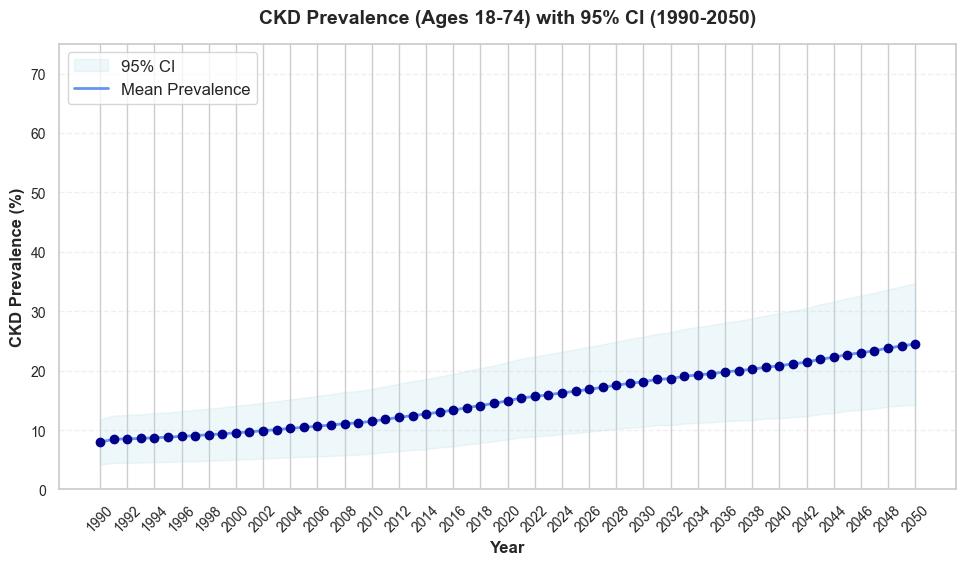

In [251]:
import matplotlib.pyplot as plt
# Set initial and final years
start_year = 1990  # Can be changed to 2000 or other year
end_year = 2050

# Create years array
years = np.arange(start_year, end_year + 1)
num_years = len(years)

# Create figure and axis
plt.figure(figsize=(10, 6))

# Plot the confidence interval as a shaded region
plt.fill_between(years, prevalence_df['k0_prevalence'][-num_years:], 
                 prevalence_df['k1_prevalence'][-num_years:], 
                 alpha=0.2, color='lightblue', label='95% CI')

# Plot the mean line
mean_prevalence = (prevalence_df['k0_prevalence'][-num_years:] + 
                  prevalence_df['k1_prevalence'][-num_years:])/2
plt.plot(years, mean_prevalence, color='#6495ED', linewidth=2, label='Mean Prevalence')

# Add dots for mean prevalence values
plt.plot(years, mean_prevalence, 'o', color='darkblue', markersize=6)

# Add specific data points
# plt.plot([2019], [8.7], 'o', color='red', markersize=8, label='2020 Data Point')
# plt.plot([2022], [13.8], 'o', color='red', markersize=8, label='2022 Data Point')

# Customize the plot
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('CKD Prevalence (%)', fontsize=12, fontweight='bold')
plt.title(f'CKD Prevalence (Ages 18-74) with 95% CI ({start_year}-{end_year})',
         fontsize=14, fontweight='bold', pad=15)

# Add grid
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Customize ticks
plt.xticks(years[::2], rotation=45)  # Show every 2nd year at 45 degree angle
plt.tick_params(axis='both', labelsize=10)
plt.ylim(0,75)
# Add legend
plt.legend(loc='upper left', fontsize=12)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()



# by thnicity, gender and age group 

# stages

# validation 

# 18 - 85 

In [ ]:
# 2022 checking 



In [179]:
idx = 2022 - 2050
idx

-28

In [189]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define ethnicity categories
categories = ['chn mal', 'chn fem', 'mal mal', 'mal fem', 'ind mal', 'ind fem']
nphs_prevalence = [11.8, 13.8, 20.7, 17.2, 17.6, 11.0]  # Target values

# Initialize lists for storing results
ethnicity_ckd_prevalences_low = []
ethnicity_ckd_prevalences_high = []

# Iterate over 6 ethnicity groups
for i in range(6):
    ages = age_matrix_vec[i][:, idx]
    age_mask = (ages >= 18) & (ages <= 74)
    total_population = np.sum(age_mask)

    # Compute CKD prevalence for k-values 0 (low) and 4 (high)
    for  k in [0, -1]:
        acr_values = albu_1_mat_storage[i][k, :, idx]  # ACR for current case
        stages_col = stage_matrix_ls[i][:, idx]

        # Filter variables based on the mask
        filtered_stages = stages_col[age_mask]
        filtered_acr = acr_values[age_mask]

        # Define healthy condition: stage 0 or 1 and ACR = 0
        healthy_mask = (filtered_stages <= 2) & (filtered_acr == 0)

        # Identify CKD cases
        total_ckd_cases = np.sum(~healthy_mask)

        # Compute prevalence
        prevalence = (total_ckd_cases / total_population) * 100 if total_population > 0 else 0

        # Store in appropriate list based on k value
        if k == 0:  # Low prevalence (k=0)
            ethnicity_ckd_prevalences_low.append(prevalence)
        else:  # High prevalence (k=4)
            ethnicity_ckd_prevalences_high.append(prevalence)




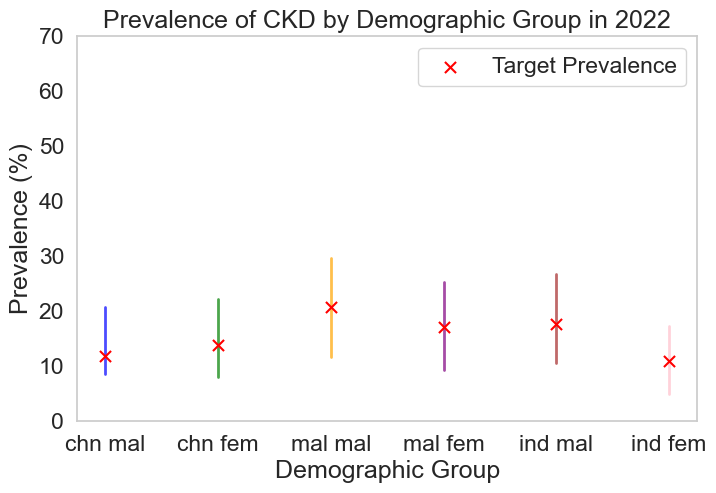

In [202]:
boxplot_data = pd.DataFrame({
    "Demographic Group": ['chn mal', 'chn fem', 'mal mal', 'mal fem', 'ind mal', 'ind fem'],
    "Lower Prevalence": ethnicity_ckd_prevalences_low,
    "Upper Prevalence": ethnicity_ckd_prevalences_high
})

df_melted = boxplot_data.melt(id_vars=["Demographic Group"], 
                              value_vars=["Lower Prevalence", "Upper Prevalence"], 
                              var_name="Bound", value_name="Prevalence")

nphs_prevalence  = [11.8, 13.8, 20.7, 17.2, 17.6, 11.0]
categories = ['chn mal', 'chn fem', 'mal mal', 'mal fem', 'ind mal', 'ind fem']
# Plot
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
# Line plot with vertical lines for CKD prevalence range
x_positions = range(len(categories))
# plt.plot(x_positions, ethnicity_ckd_prevalences_low, 'o-', color='blue', label='Lower Prevalence')
# plt.plot(x_positions, ethnicity_ckd_prevalences_high, 'o-', color='lightblue', label='Upper Prevalence')

# Draw vertical lines connecting lower and upper prevalence for each group
colors = ['blue', 'green', 'orange', 'purple', 'brown', 'pink']
for i, (low, high) in enumerate(zip(ethnicity_ckd_prevalences_low, ethnicity_ckd_prevalences_high)):
    plt.plot([i, i], [low, high], color=colors[i], alpha=0.7, linewidth=2)

plt.xticks(x_positions, categories)

# Overlay the target prevalence as points
plt.scatter(x_positions, nphs_prevalence, color="red", 
           s=64, label="Target Prevalence", zorder=5, marker='x')

plt.grid(False)


# Labels and title
plt.ylim(0, 70)
plt.xlabel("Demographic Group")
plt.ylabel("Prevalence (%)")
plt.title("Prevalence of CKD by Demographic Group in 2022")
plt.legend()

# Show plot
plt.show()

In [185]:
results

[{'Ethnicity': 'chn mal', 'Prevalence (%)': 8.586204534557162},
 {'Ethnicity': 'chn mal', 'Prevalence (%)': 20.78567025138708},
 {'Ethnicity': 'chn fem', 'Prevalence (%)': 7.993768560440095},
 {'Ethnicity': 'chn fem', 'Prevalence (%)': 22.313097382470833},
 {'Ethnicity': 'mal mal', 'Prevalence (%)': 11.690465223399354},
 {'Ethnicity': 'mal mal', 'Prevalence (%)': 29.62690004606172},
 {'Ethnicity': 'mal fem', 'Prevalence (%)': 9.292687419414257},
 {'Ethnicity': 'mal fem', 'Prevalence (%)': 25.299318474857245},
 {'Ethnicity': 'ind mal', 'Prevalence (%)': 10.556548378861374},
 {'Ethnicity': 'ind mal', 'Prevalence (%)': 26.831758999234108},
 {'Ethnicity': 'ind fem', 'Prevalence (%)': 4.960942853227354},
 {'Ethnicity': 'ind fem', 'Prevalence (%)': 17.377004248321228}]

In [192]:
import pandas as pd
import numpy as np

# Define age groups
age_ranges = ["18-39", "40-54", "55-69", "70-74"]

# Initialize lists to store prevalence values
low_prevalence = []
upper_prevalence = []

for a_1, a_2 in [(18, 39), (40, 54), (55, 69), (70, 74)]:
    total_population = 0
    total_ckd_cases = {"low": 0, "upper": 0}
    
    for i in range(8):  # Iterate over 8 ethnicity groups
        ages = age_matrix_vec[i][:, idx]
        stages_col = stage_matrix_ls[i][:, idx]
        age_mask = (ages >= a_1) & (ages <= a_2)
        filtered_stages = stages_col[age_mask]
        
        for label, threshold in zip(["low", "upper"], [0, -1]):
            acr_values = albu_mat_storage[i][threshold, :, idx]
            filtered_acr = acr_values[age_mask]
            healthy_mask = (filtered_stages <= 2) & (filtered_acr == 0)
            non_healthy_mask = ~healthy_mask
            total_ckd_cases[label] += np.sum(non_healthy_mask)
        
        total_population += np.sum(age_mask)
    
    low_prevalence.append((total_ckd_cases["low"] / total_population) * 100)
    upper_prevalence.append((total_ckd_cases["upper"] / total_population) * 100)

# Create DataFrame
target_values = [5, 10, 21, 36]
ckd_prevalence_df = pd.DataFrame({
    "Age Range": age_ranges,
    "Low Prevalence": upper_prevalence,
    "Upper Prevalence": low_prevalence,
    "Target": target_values
})

# Display DataFrame
print(ckd_prevalence_df)



  Age Range  Low Prevalence  Upper Prevalence  Target
0     18-39       16.305530          3.590268       5
1     40-54       17.328904          4.141646      10
2     55-69       29.636573         15.467667      21
3     70-74       44.371192         30.306663      36


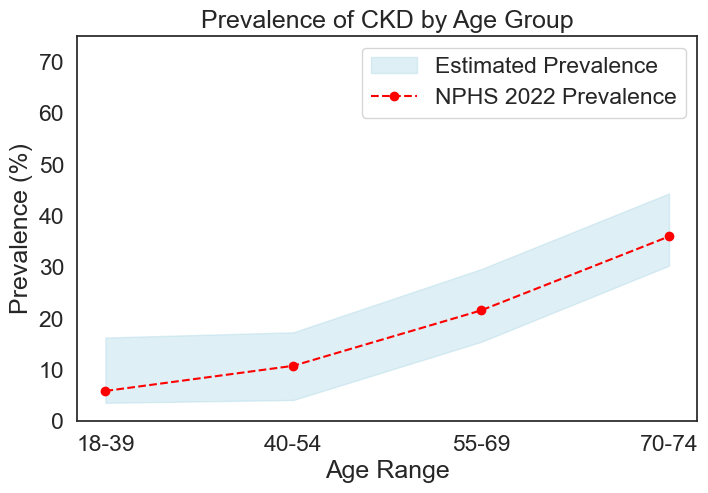

In [193]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data
data = {
    "Age Range": ["18-39", "40-54", "55-69", "70-74"],
    "Low Prevalence": low_prevalence,
    "Upper Prevalence": upper_prevalence,
    "Target": [5.9, 10.8, 21.6, 36]
}
df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(8, 5))
sns.set_style("white")

# Shaded area for prevalence range
plt.fill_between(df["Age Range"], df["Low Prevalence"], df["Upper Prevalence"], color="lightblue", alpha=0.4, label="Estimated Prevalence")

# Line for target prevalence
plt.plot(df["Age Range"], df["Target"], marker="o", linestyle="--", color="red", label="NPHS 2022 Prevalence")
plt.ylim(0,75)
# Labels and title
plt.xlabel("Age Range")
plt.ylabel("Prevalence (%)")
plt.title("Prevalence of CKD by Age Group")
plt.legend()
# Show plot
plt.show()
